# Imports and drive

In [44]:
# import the necessary packages
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
import cv2

import os
import random


# Read images and create dataset

Se debe descargar el conjunto de datos de: https://github.com/rubenchov/aprendizajeautomaticovision/tree/main/Conjuntos%20de%20datos/3%20Escenas

Se debe ubicar en una carpeta en su Drive y actualizar el siguiente enlace para que esté bien enrutado.

In [45]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    datadir = '/content/drive/MyDrive/2025/Docencia/Visión e IA/2. Aprendizaje Automático' #Actualizar ruta dependiendo de dónde tenga su conjunto de datos (la carpeta que contiene '3scenes')
except ImportError:
    datadir = '.'
folder = '3scenes' #Apunta a una subcarpeta que se denomine así
subfolders = ['coast', 'forest', 'highway'] #Define las subcarpetas que se van a explorar

paths = []
data = []
labels = []
for subfolder in subfolders:
  print(subfolder)
  subfolder_path = os.path.join(datadir, folder, subfolder)
  files = sorted(f for f in os.listdir(subfolder_path) if f.endswith('.jpg'))
  for file in files:
    path = os.path.join(subfolder_path, file)
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
      print('No se pudo leer:', path)
      continue
    paths.append(path)
    B, G, R = cv2.split(img)
    features = [np.mean(R), np.mean(G), np.mean(B), np.std(R), np.std(G), np.std(B)]
    data.append(features)
    labels.append(subfolder)


coast
forest
highway


In [46]:
indice = 5
print('Ruta: ', paths[indice])
print('Características (X): ', data[indice])
print('Etiqueta (Y): ', labels[indice])

Ruta:  ./3scenes/coast/coast_bea10.jpg
Características (X):  [np.float64(130.94740295410156), np.float64(160.6336669921875), np.float64(133.16001892089844), np.float64(76.28546155435848), np.float64(67.53294609255461), np.float64(61.81168399735206)]
Etiqueta (Y):  coast


In [47]:
# encode the labels, converting them from strings to integers
le = LabelEncoder()
labels = le.fit_transform(labels)

# Split dataset into train and test

In [48]:
# perform a training and testing split, using 75% of the data for
# training and 25% for evaluation
(trainX, testX, trainY, testY) = train_test_split(np.array(data), np.array(labels), test_size=0.25, random_state=20)

# Define model

In [49]:
#model = KNeighborsClassifier()
#model = GaussianNB()
#model = SVC()
#model = DecisionTreeClassifier()
#model = RandomForestClassifier()
model = MLPClassifier()

*Ejercicio propuesto: Se recomienda modificar el comentario para activar o desactivar modelos y evaluar su desempeño. Además modificar hiperparámetros.*

# Compile model and train

In [50]:
model.fit(trainX, trainY)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


# Evaluate model

In [51]:
predictions = model.predict(testX)
print(classification_report(testY, predictions,	target_names=le.classes_))
print('Accuracy: ', model.score(testX, testY)*100)

              precision    recall  f1-score   support

       coast       0.79      0.87      0.83        91
      forest       0.95      0.79      0.86        87
     highway       0.70      0.76      0.73        62

    accuracy                           0.81       240
   macro avg       0.81      0.81      0.81       240
weighted avg       0.82      0.81      0.81       240

Accuracy:  81.25


Tomar nota de esta exactitud, y con ello comparar con otros modelos encontrados.

# Test on random sample

In [52]:
rand_pos = random.randint(0, len(paths))
print('Path: ', paths[rand_pos])
img = cv2.imread(paths[rand_pos])
B, G, R = cv2.split(img)
feature = [np.mean(R), np.mean(G), np.mean(B), np.std(R), np.std(G), np.std(B)]
pred = model.predict([feature])
print('Predicted class: ', le.classes_[pred][0])


Path:  ./3scenes/highway/highway_art250.jpg
Predicted class:  coast


Matriz de confusión

['coast' 'forest' 'highway']


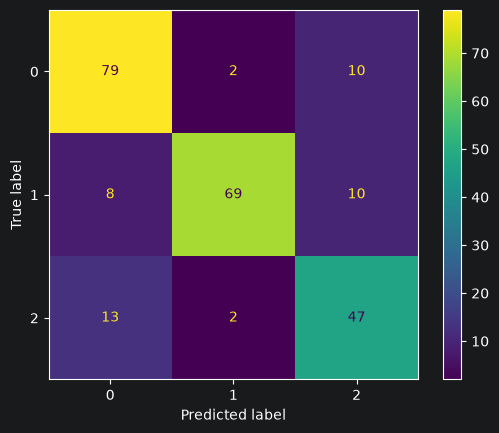

In [53]:
print(le.classes_)
ConfusionMatrixDisplay.from_predictions(testY, predictions)

# Ampliación: nuevas características (HSV, Haralick) y los 9 modelos de los retos anteriores

**Objetivos del ejercicio:**

1. Características base: media y desviación estándar de los canales R, G, B (baseline ya implementado arriba).
2. Explorar nuevas características: espacio de color **HSV** y textura con los **descriptores de Haralick** (GLCM).
3. Entrenar los **9 modelos** de los retos anteriores: KNN, Bayes Gaussiano, Regresión Logística, SVM, Árbol de Decisión, Bosque Aleatorio, Perceptrón Multicapa, **Stacking** y **Kmeans** (ensambles del Reto de Flores, parte 4).
4. Validar con partición estratificada y validación cruzada de 5 pliegues.
5. Comparar los bloques **RGB**, **HSV**, **Haralick**, **RGB+HSV** y **RGB+HSV+Haralick** (con y sin el RGB original).
6. Analizar resultados y redactar conclusiones. La fundamentación matemática completa está en `informe.md`.

## Instalación de dependencias

Los descriptores de Haralick se calculan con la librería `mahotas` (si falta, se instala automáticamente). En local se recomienda el entorno conda `base`, que ya incluye todas las dependencias (numpy, scikit-learn, opencv, pandas, matplotlib, mahotas).

In [54]:
try:
    import mahotas
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mahotas'])
    import mahotas
print('mahotas', mahotas.__version__)

mahotas 1.4.18


## Extracción de características

**RGB (6 características).** Momentos estadísticos de primer y segundo orden de cada canal $c \in \{R,G,B\}$:


**HSV (6 características).** El espacio HSV desacopla la cromaticidad (tono $H$ y saturación $S$) de la luminancia ($V$), por lo que es más robusto a cambios de iluminación que el RGB crudo. Se extraen $\mu$ y $\sigma$ de cada canal tras convertir con `cv2.cvtColor(BGR2HSV)` (en OpenCV, $H\in[0,179]$ y $S,V\in[0,255]$).

**Haralick (13 características).** Sobre la imagen en escala de grises se construye la **matriz de coocurrencia de niveles de gris (GLCM)**, $P_{d,\theta}(i,j)$, que cuenta la frecuencia con la que dos píxeles separados una distancia $d$ en la dirección $\theta$ toman los niveles de gris $i$ y $j$. De la GLCM se derivan 13 descriptores de textura (energía, contraste, correlación, entropía, homogeneidad, ...), promediados en las 4 direcciones $\theta\in\{0°,45°,90°,135°\}$.

La combinación "con y sin RGB" da lugar a los 5 bloques comparables: `RGB`, `HSV`, `Haralick`, `RGB+HSV` y `RGB+HSV+Haralick`.

In [55]:
def extraer_caracteristicas(img):
    """Características RGB, HSV y Haralick de una imagen BGR."""
    # RGB: media y desviación estándar de cada canal (igual que el baseline)
    B, G, R = cv2.split(img)
    f_rgb = [np.mean(R), np.mean(G), np.mean(B), np.std(R), np.std(G), np.std(B)]
    # HSV: mismos estadísticos en el espacio tono/saturación/valor
    H, S, V = cv2.split(cv2.cvtColor(img, cv2.COLOR_BGR2HSV))
    f_hsv = [np.mean(H), np.mean(S), np.mean(V), np.std(H), np.std(S), np.std(V)]
    # Haralick: 13 descriptores de textura a partir de la GLCM (promedio de las 4 direcciones)
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    f_har = list(mahotas.features.haralick(gris).mean(axis=0))
    return f_rgb, f_hsv, f_har

data_rgb, data_hsv, data_har, labels_ampl = [], [], [], []
for path in paths:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        print('No se pudo leer:', path)
        continue
    f_rgb, f_hsv, f_har = extraer_caracteristicas(img)
    data_rgb.append(f_rgb)
    data_hsv.append(f_hsv)
    data_har.append(f_har)
    labels_ampl.append(os.path.basename(os.path.dirname(path)))

# Bloques de características a comparar (con y sin el RGB del baseline)
bloques = {
    'RGB (6)': np.array(data_rgb, dtype=float),
    'HSV (6)': np.array(data_hsv, dtype=float),
    'Haralick (13)': np.array(data_har, dtype=float),
    'RGB+HSV (12)': np.array([a + b for a, b in zip(data_rgb, data_hsv)], dtype=float),
    'RGB+HSV+Haralick (25)': np.array([a + b + c for a, b, c in zip(data_rgb, data_hsv, data_har)], dtype=float),
}
y_ampl = np.array(labels_ampl)

print('Muestras:', len(y_ampl), '| Clases:', dict(zip(*np.unique(y_ampl, return_counts=True))))
for nombre, X in bloques.items():
    print(f'{nombre}: matriz {X.shape}')

Muestras: 958 | Clases: {np.str_('coast'): np.int64(360), np.str_('forest'): np.int64(328), np.str_('highway'): np.int64(270)}
RGB (6): matriz (958, 6)
HSV (6): matriz (958, 6)
Haralick (13): matriz (958, 13)
RGB+HSV (12): matriz (958, 12)
RGB+HSV+Haralick (25): matriz (958, 25)


## Los 9 modelos

Se comparan 8 modelos supervisados más una exploración **no supervisada** con K-means (parte 3 del Reto de Flores). El método del codo y la matriz de confusión de K-means están en las celdas finales, tras la verificación.

| # | Modelo | Reto de origen | Escalado |
|---|---|---|---|
| 1 | KNeighborsClassifier | Baseline 3scenes / parte 3 | Sí (basado en distancias) |
| 2 | GaussianNB | Reto de Flores, parte 2 | No (invariante) |
| 3 | LogisticRegression | Reto de Flores, parte 1 | Sí (optimización por gradiente) |
| 4 | SVC (kernel RBF) | Reto de Flores, parte 2 | Sí (kernel depende de distancias) |
| 5 | DecisionTreeClassifier | Reto de Flores, parte 1 | No (invariante) |
| 6 | RandomForestClassifier | Reto de Flores, parte 1 | No |
| 7 | MLPClassifier | Reto de Flores, parte 3 | Sí (descenso de gradiente) |
| 8 | StackingClassifier | Reto de Flores, parte 4 | Bases escaladas |
| 9 | KMeans (no supervisado) | Reto de Flores, parte 3 | Sí (distancias euclídeas) |

El `StandardScaler` se integra dentro de un `Pipeline` y se ajusta **solo con los datos de entrenamiento** de cada fold, evitando fuga de datos.

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import StackingClassifier
import pandas as pd

# Estimadores base del ensamble Stacking
base = [
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier())),
    ('svc', make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
]

def construir_modelos():
    """Los 9 modelos, envueltos en un Pipeline con StandardScaler si son sensibles a la escala."""
    return {
        'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier()),
        'GaussianNB': GaussianNB(),
        'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=42)),
        'SVC': make_pipeline(StandardScaler(), SVC(random_state=42)),
        'DecisionTree': DecisionTreeClassifier(random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'MLP': make_pipeline(StandardScaler(), MLPClassifier(max_iter=2000, random_state=42)),
        'Stacking': StackingClassifier(
            estimators=base,
            final_estimator=make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
            cv=5, stack_method='predict_proba'),
    }

orden_modelos = list(construir_modelos())
orden_bloques = list(bloques)
print('8 modelos supervisados:', orden_modelos)

8 modelos supervisados: ['KNN', 'GaussianNB', 'LogisticRegression', 'SVC', 'DecisionTree', 'RandomForest', 'MLP', 'Stacking']


## Entrenamiento y validación



In [57]:
from time import time

resultados = []
for nombre_bloque, X in bloques.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_ampl, test_size=0.25, stratify=y_ampl, random_state=20)
    for nombre_modelo in orden_modelos:
        modelo = construir_modelos()[nombre_modelo]
        t0 = time()
        cv = cross_val_score(modelo, X_tr, y_tr, cv=5)  # validación cruzada 5 pliegues
        modelo.fit(X_tr, y_tr)                          # entrenamiento final
        acc_test = modelo.score(X_te, y_te)             # evaluación en test
        resultados.append({'Bloque': nombre_bloque, 'Modelo': nombre_modelo,
                           'Accuracy CV': cv.mean(), 'Std CV': cv.std(),
                           'Accuracy test': acc_test, 'Tiempo (s)': round(time() - t0, 2)})
        print(f"{nombre_bloque:>22} | {nombre_modelo:>16} | CV {cv.mean():.4f} ± {cv.std():.4f} | test {acc_test:.4f}")

df_resultados = pd.DataFrame(resultados)

               RGB (6) |              KNN | CV 0.7535 ± 0.0336 | test 0.7375
               RGB (6) |       GaussianNB | CV 0.6449 ± 0.0230 | test 0.6125
               RGB (6) | LogisticRegression | CV 0.7703 ± 0.0343 | test 0.7500
               RGB (6) |              SVC | CV 0.8107 ± 0.0519 | test 0.7958
               RGB (6) |     DecisionTree | CV 0.7159 ± 0.0193 | test 0.6750
               RGB (6) |     RandomForest | CV 0.8023 ± 0.0340 | test 0.7958


/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14

               RGB (6) |              MLP | CV 0.8065 ± 0.0473 | test 0.8208


/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

               RGB (6) |         Stacking | CV 0.8148 ± 0.0458 | test 0.8083
               HSV (6) |              KNN | CV 0.7632 ± 0.0320 | test 0.7417
               HSV (6) |       GaussianNB | CV 0.6768 ± 0.0268 | test 0.6708
               HSV (6) | LogisticRegression | CV 0.7020 ± 0.0258 | test 0.6667
               HSV (6) |              SVC | CV 0.7981 ± 0.0274 | test 0.7708
               HSV (6) |     DecisionTree | CV 0.6698 ± 0.0411 | test 0.6958
               HSV (6) |     RandomForest | CV 0.7772 ± 0.0254 | test 0.7833


/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14

               HSV (6) |              MLP | CV 0.7883 ± 0.0309 | test 0.7625


/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

               HSV (6) |         Stacking | CV 0.8050 ± 0.0214 | test 0.7833
         Haralick (13) |              KNN | CV 0.8273 ± 0.0285 | test 0.8292
         Haralick (13) |       GaussianNB | CV 0.7841 ± 0.0303 | test 0.7542
         Haralick (13) | LogisticRegression | CV 0.8036 ± 0.0261 | test 0.8042
         Haralick (13) |              SVC | CV 0.8370 ± 0.0122 | test 0.8208
         Haralick (13) |     DecisionTree | CV 0.8064 ± 0.0103 | test 0.7833
         Haralick (13) |     RandomForest | CV 0.8649 ± 0.0178 | test 0.8542
         Haralick (13) |              MLP | CV 0.8803 ± 0.0244 | test 0.8625


/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

         Haralick (13) |         Stacking | CV 0.8649 ± 0.0106 | test 0.8542
          RGB+HSV (12) |              KNN | CV 0.7925 ± 0.0329 | test 0.7708
          RGB+HSV (12) |       GaussianNB | CV 0.6880 ± 0.0281 | test 0.6458
          RGB+HSV (12) | LogisticRegression | CV 0.8037 ± 0.0349 | test 0.7958
          RGB+HSV (12) |              SVC | CV 0.8259 ± 0.0351 | test 0.8042
          RGB+HSV (12) |     DecisionTree | CV 0.7270 ± 0.0193 | test 0.7042
          RGB+HSV (12) |     RandomForest | CV 0.8162 ± 0.0277 | test 0.7917
          RGB+HSV (12) |              MLP | CV 0.8301 ± 0.0267 | test 0.8208


/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

          RGB+HSV (12) |         Stacking | CV 0.8217 ± 0.0282 | test 0.8125
 RGB+HSV+Haralick (25) |              KNN | CV 0.8663 ± 0.0291 | test 0.8333
 RGB+HSV+Haralick (25) |       GaussianNB | CV 0.8092 ± 0.0151 | test 0.7750
 RGB+HSV+Haralick (25) | LogisticRegression | CV 0.8970 ± 0.0274 | test 0.8875
 RGB+HSV+Haralick (25) |              SVC | CV 0.9081 ± 0.0262 | test 0.8875
 RGB+HSV+Haralick (25) |     DecisionTree | CV 0.8120 ± 0.0229 | test 0.8208
 RGB+HSV+Haralick (25) |     RandomForest | CV 0.9011 ± 0.0135 | test 0.9000
 RGB+HSV+Haralick (25) |              MLP | CV 0.9067 ± 0.0258 | test 0.8917


/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

 RGB+HSV+Haralick (25) |         Stacking | CV 0.9025 ± 0.0271 | test 0.8833


In [58]:
# Tablas pivote: accuracy por modelo y bloque (validación cruzada y test)
tabla_cv = df_resultados.pivot(index='Modelo', columns='Bloque', values='Accuracy CV').loc[orden_modelos, orden_bloques]
tabla_test = df_resultados.pivot(index='Modelo', columns='Bloque', values='Accuracy test').loc[orden_modelos, orden_bloques]

try:
    display(tabla_cv.style.format('{:.4f}').background_gradient(cmap='Greens', axis=None).set_caption('Accuracy (media CV 5 pliegues)'))
    display(tabla_test.style.format('{:.4f}').background_gradient(cmap='Blues', axis=None).set_caption('Accuracy (test 25%)'))
except Exception:
    print(tabla_cv.round(4))
    print()
    print(tabla_test.round(4))

Bloque,RGB (6),HSV (6),Haralick (13),RGB+HSV (12),RGB+HSV+Haralick (25)
Modelo,,,,,
KNN,0.7535,0.7632,0.8273,0.7925,0.8663
GaussianNB,0.6449,0.6768,0.7841,0.6880,0.8092
LogisticRegression,0.7703,0.7020,0.8036,0.8037,0.8970
SVC,0.8107,0.7981,0.8370,0.8259,0.9081
DecisionTree,0.7159,0.6698,0.8064,0.7270,0.8120
RandomForest,0.8023,0.7772,0.8649,0.8162,0.9011
MLP,0.8065,0.7883,0.8803,0.8301,0.9067
Stacking,0.8148,0.8050,0.8649,0.8217,0.9025


Bloque,RGB (6),HSV (6),Haralick (13),RGB+HSV (12),RGB+HSV+Haralick (25)
Modelo,,,,,
KNN,0.7375,0.7417,0.8292,0.7708,0.8333
GaussianNB,0.6125,0.6708,0.7542,0.6458,0.7750
LogisticRegression,0.7500,0.6667,0.8042,0.7958,0.8875
SVC,0.7958,0.7708,0.8208,0.8042,0.8875
DecisionTree,0.6750,0.6958,0.7833,0.7042,0.8208
RandomForest,0.7958,0.7833,0.8542,0.7917,0.9000
MLP,0.8208,0.7625,0.8625,0.8208,0.8917
Stacking,0.8083,0.7833,0.8542,0.8125,0.8833


Mejor combinación: SVC + RGB+HSV+Haralick (25)
CV: 0.9081 ± 0.0262 | Test: 0.8875

              precision    recall  f1-score   support

       coast     0.8333    0.8889    0.8602        90
      forest     0.9310    0.9878    0.9586        82
     highway     0.9123    0.7647    0.8320        68

    accuracy                         0.8875       240
   macro avg     0.8922    0.8805    0.8836       240
weighted avg     0.8891    0.8875    0.8858       240



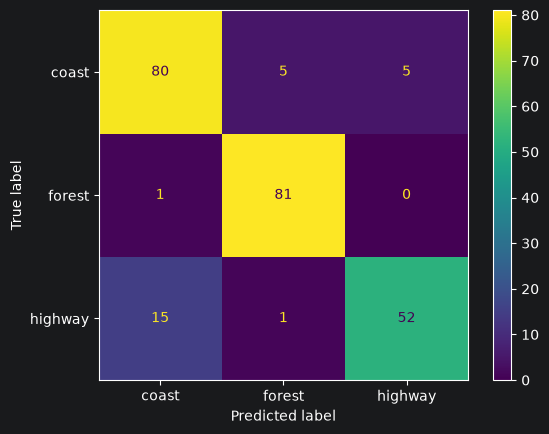

In [59]:
# Mejor combinación: informe de clasificación y matriz de confusión en test
mejor = df_resultados.sort_values('Accuracy CV', ascending=False).iloc[0]
print(f"Mejor combinación: {mejor['Modelo']} + {mejor['Bloque']}")
print(f"CV: {mejor['Accuracy CV']:.4f} ± {mejor['Std CV']:.4f} | Test: {mejor['Accuracy test']:.4f}\n")

X = bloques[mejor['Bloque']]
X_tr, X_te, y_tr, y_te = train_test_split(X, y_ampl, test_size=0.25, stratify=y_ampl, random_state=20)
modelo_mejor = construir_modelos()[mejor['Modelo']].fit(X_tr, y_tr)
pred_mejor = modelo_mejor.predict(X_te)
print(classification_report(y_te, pred_mejor, digits=4))
ConfusionMatrixDisplay.from_predictions(y_te, pred_mejor, xticks_rotation='horizontal')

## Análisis y conclusiones

Puntos clave a observar tras ejecutar:

1. **HSV frente a RGB**: separar tono/saturación de luminancia suele mejorar la discriminación entre escenas con paletas distintas (mar/cielo en `coast`, vegetación en `forest`, asfalto en `highway`).
2. **Haralick**: la textura de segundo orden (GLCM) captura estructuras que los momentos de color no ven: follaje de alta frecuencia en `forest`, superficies lisas (mar/cielo) en `coast` y bordes direccionales en `highway`.
3. **Combinar bloques**: más información, pero también redundancia y correlación (RGB y HSV comparten la luminancia). Beneficia a modelos no lineales robustos (RF, SVC, ensambles) y puede perjudicar a GaussianNB (viola la independencia condicional) y a KNN (maldición de la dimensionalidad).
4. **Modelos**: los árboles y sus ensambles son invariantes a la escala; KNN/SVC/MLP/Regresión Logística la necesitan (aquí la aplican dentro del Pipeline). Los ensambles (RF, Stacking) reducen la varianza y tienden a quedar en los primeros puestos.
5. **Comparar con el baseline** de las secciones anteriores (MLP + RGB: 81.25 % en test) para sustentar cuantitativamente la mejora obtenida con las nuevas características.


## Gráficas y verificación de los modelos



In [61]:
# Configuración común de las gráficas y la verificación (se apoya en los resultados ya calculados)
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, learning_curve, validation_curve, cross_val_score
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
import pandas as pd

os.makedirs('figuras', exist_ok=True)

# Bloque ganador, mejor modelo y partición fija (idéntica a la de los 45 experimentos)
bloque_ganador = df_resultados.sort_values('Accuracy CV', ascending=False).iloc[0]['Bloque']
mejor_modelo_nombre = df_resultados.sort_values('Accuracy CV', ascending=False).iloc[0]['Modelo']
Xg = bloques[bloque_ganador]
idx = np.arange(len(y_ampl))
idx_tr, idx_te = train_test_split(idx, test_size=0.25, stratify=y_ampl, random_state=20)
Xg_tr, Xg_te, yg_tr, yg_te = Xg[idx_tr], Xg[idx_te], y_ampl[idx_tr], y_ampl[idx_te]
cv5 = StratifiedKFold(n_splits=5)  # mismo esquema que cv=5 usado en los experimentos
clases = np.unique(y_ampl)

def guardar(fig, nombre):
    # Guarda cada figura como PNG para la evidencia del informe
    fig.savefig(f'figuras/{nombre}.png', dpi=150, bbox_inches='tight')
    print('Figura guardada: figuras/' + nombre + '.png')

print('Bloque ganador:', bloque_ganador, '| Mejor modelo:', mejor_modelo_nombre)

Bloque ganador: RGB+HSV+Haralick (25) | Mejor modelo: SVC


### Gráficas

Figura guardada: figuras/figura1_heatmap_accuracy_cv.png


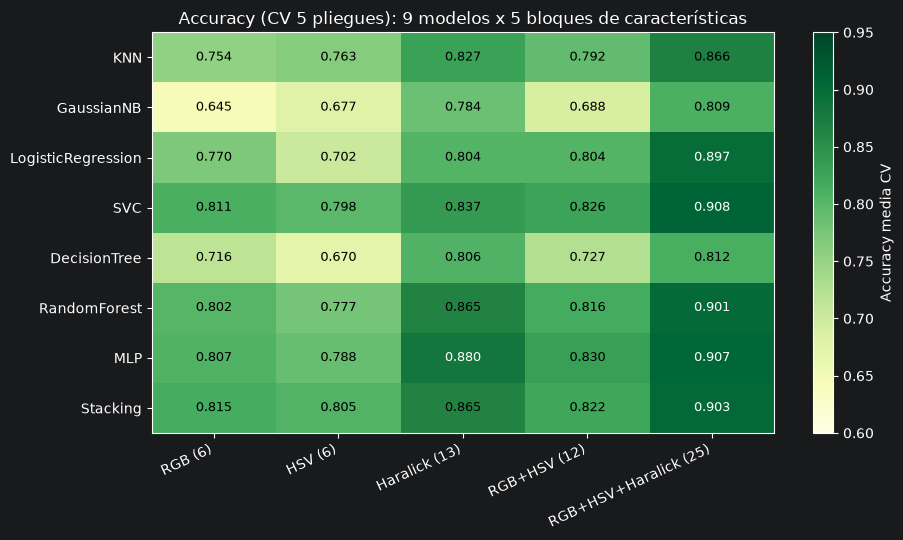

In [62]:
# G1. Heatmap: accuracy CV de los 45 experimentos (9 modelos x 5 bloques)
fig, ax = plt.subplots(figsize=(9.5, 5.5))
im = ax.imshow(tabla_cv.values, cmap='YlGn', aspect='auto', vmin=0.6, vmax=0.95)
ax.set_xticks(range(len(tabla_cv.columns)), tabla_cv.columns, rotation=25, ha='right')
ax.set_yticks(range(len(tabla_cv.index)), tabla_cv.index)
for i in range(tabla_cv.shape[0]):
    for j in range(tabla_cv.shape[1]):
        v = tabla_cv.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9,
                color='black' if v < 0.88 else 'white')
fig.colorbar(im, ax=ax, label='Accuracy media CV')
ax.set_title('Accuracy (CV 5 pliegues): 9 modelos x 5 bloques de características')
fig.tight_layout()
guardar(fig, 'figura1_heatmap_accuracy_cv')
plt.show()

/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

Figura guardada: figuras/figura4_f1_por_clase_top5.png


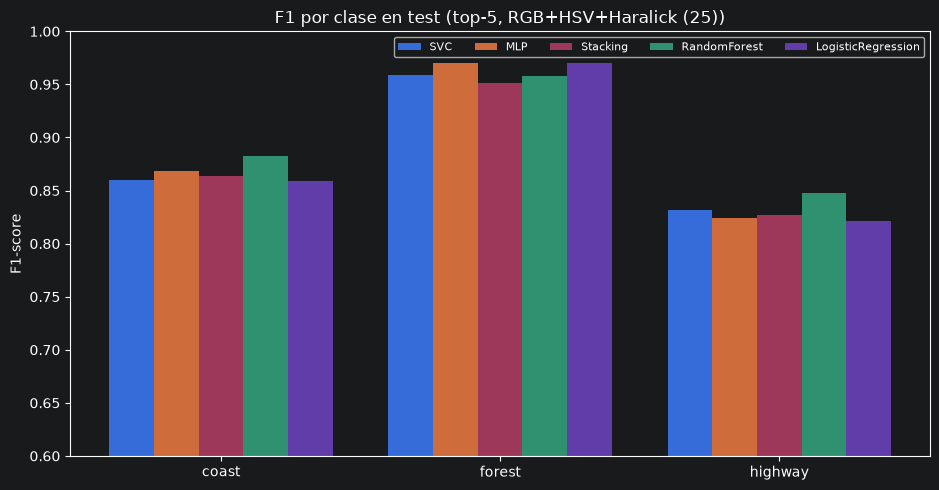

|         |    SVC |    MLP |   Stacking |   RandomForest |   LogisticRegression |
|:--------|-------:|-------:|-----------:|---------------:|---------------------:|
| coast   | 0.8602 | 0.8681 |     0.8634 |         0.883  |               0.8587 |
| forest  | 0.9586 | 0.9701 |     0.9512 |         0.9581 |               0.9701 |
| highway | 0.832  | 0.8244 |     0.8271 |         0.848  |               0.8217 |


In [63]:
# G4. F1-score por clase en test para el top-5 de modelos
top5 = df_resultados[df_resultados['Bloque'] == bloque_ganador].nlargest(5, 'Accuracy CV')['Modelo'].tolist()
f1_clase = {}
for m in top5:
    pred = construir_modelos()[m].fit(Xg_tr, yg_tr).predict(Xg_te)
    f1_clase[m] = f1_score(yg_te, pred, labels=clases, average=None)

x = np.arange(len(clases))
w = 0.8 / len(top5)
fig, ax = plt.subplots(figsize=(9.5, 5))
for i, m in enumerate(top5):
    ax.bar(x + i * w, f1_clase[m], w, label=m)
ax.set_xticks(x + w * (len(top5) - 1) / 2, clases)
ax.set_ylabel('F1-score')
ax.set_ylim(0.6, 1.0)
ax.set_title(f'F1 por clase en test (top-5, {bloque_ganador})')
ax.legend(ncol=5, fontsize=8)
fig.tight_layout()
guardar(fig, 'figura4_f1_por_clase_top5')
plt.show()
print(pd.DataFrame(f1_clase, index=clases).round(4).to_markdown())

### Matrices de confusión normalizadas (top-3)

Cada fila se normaliza por su soporte (tasa de acierto/error por clase real), lo que permite comparar modelos aunque el número de ejemplos difiera entre clases.

/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

Figura guardada: figuras/figura5_matriz_confusion_top3.png


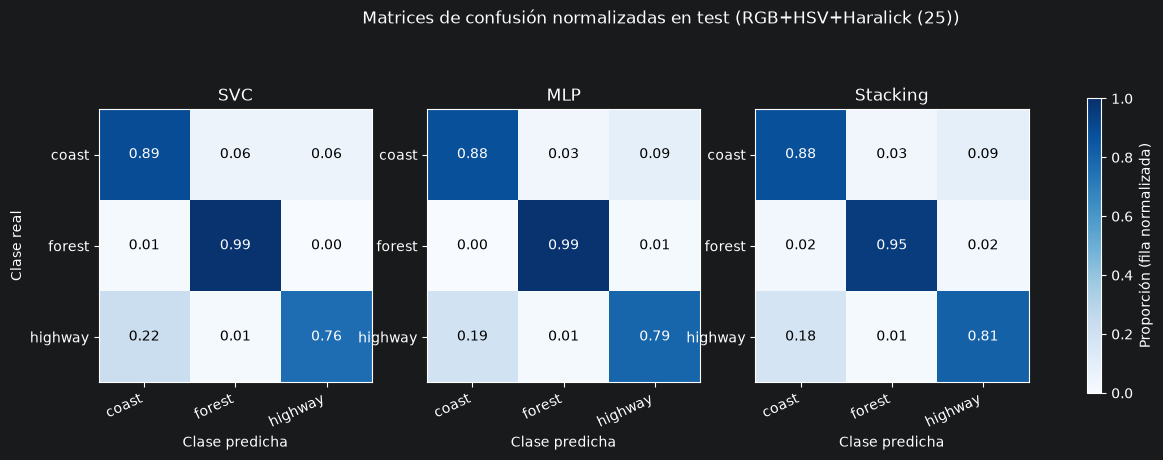


SVC (filas: clase real):
|         |   coast |   forest |   highway |
|:--------|--------:|---------:|----------:|
| coast   |  0.8889 |   0.0556 |    0.0556 |
| forest  |  0.0122 |   0.9878 |    0      |
| highway |  0.2206 |   0.0147 |    0.7647 |

MLP (filas: clase real):
|         |   coast |   forest |   highway |
|:--------|--------:|---------:|----------:|
| coast   |  0.8778 |   0.0333 |    0.0889 |
| forest  |  0      |   0.9878 |    0.0122 |
| highway |  0.1912 |   0.0147 |    0.7941 |

Stacking (filas: clase real):
|         |   coast |   forest |   highway |
|:--------|--------:|---------:|----------:|
| coast   |  0.8778 |   0.0333 |    0.0889 |
| forest  |  0.0244 |   0.9512 |    0.0244 |
| highway |  0.1765 |   0.0147 |    0.8088 |


In [64]:
# G5. Matrices de confusión normalizadas del top-3 en el bloque ganador
top3 = df_resultados[df_resultados['Bloque'] == bloque_ganador].nlargest(3, 'Accuracy CV')['Modelo'].tolist()
cms = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, m in zip(axes, top3):
    pred = construir_modelos()[m].fit(Xg_tr, yg_tr).predict(Xg_te)
    cms[m] = confusion_matrix(yg_te, pred, labels=clases, normalize='true')
    im_ = ax.imshow(cms[m], cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(clases)), clases, rotation=25, ha='right')
    ax.set_yticks(range(len(clases)), clases)
    for i in range(len(clases)):
        for j in range(len(clases)):
            ax.text(j, i, f'{cms[m][i, j]:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if cms[m][i, j] > 0.5 else 'black')
    ax.set_title(m)
    ax.set_xlabel('Clase predicha')
    if ax is axes[0]:
        ax.set_ylabel('Clase real')
fig.colorbar(im_, ax=axes, shrink=0.85, label='Proporción (fila normalizada)')
fig.suptitle(f'Matrices de confusión normalizadas en test ({bloque_ganador})', y=1.02)
fig.savefig('figuras/figura5_matriz_confusion_top3.png', dpi=150, bbox_inches='tight')
print('Figura guardada: figuras/figura5_matriz_confusion_top3.png')
plt.show()
for m in top3:
    print(f'\n{m} (filas: clase real):')
    print(pd.DataFrame(cms[m].round(4), index=clases, columns=clases).to_markdown())

### Verificación estadística: F1

In [76]:
# V1. Tabla de verificación en el bloque ganador: accuracy con IC 95%, F1 macro y weighted (CV 5 pliegues)
filas = []
for nombre in orden_modelos:
    accs, f1ms, f1ws = [], [], []
    for tr_i, va_i in cv5.split(Xg_tr, yg_tr):
        modelo = construir_modelos()[nombre].fit(Xg_tr[tr_i], yg_tr[tr_i])
        pred = modelo.predict(Xg_tr[va_i])
        accs.append(accuracy_score(yg_tr[va_i], pred))
        f1ms.append(f1_score(yg_tr[va_i], pred, average='macro'))
        f1ws.append(f1_score(yg_tr[va_i], pred, average='weighted'))
    accs = np.array(accs)
    filas.append({
        'Modelo': nombre,
        'Accuracy CV': accs.mean(),
        'IC 95% (±)': 1.96 * accs.std(ddof=1) / np.sqrt(len(accs)),
        'F1 macro CV': np.mean(f1ms),
        'F1 weighted CV': np.mean(f1ws),
    })
tabla_verificacion = pd.DataFrame(filas).sort_values('Accuracy CV', ascending=False).reset_index(drop=True)
tabla_verificacion.index += 1
tabla_verificacion.index.name = 'Ranking'
print(f'Bloque: {bloque_ganador}\n')
print(tabla_verificacion.round(4).to_markdown())

/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/chewi/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

Bloque: RGB+HSV+Haralick (25)

|   Ranking | Modelo             |   Accuracy CV |   IC 95% (±) |   F1 macro CV |   F1 weighted CV |
|----------:|:-------------------|--------------:|-------------:|--------------:|-----------------:|
|         1 | SVC                |        0.9081 |       0.0257 |        0.906  |           0.9077 |
|         2 | MLP                |        0.9067 |       0.0253 |        0.9048 |           0.9066 |
|         3 | Stacking           |        0.9025 |       0.0266 |        0.8997 |           0.9019 |
|         4 | RandomForest       |        0.9011 |       0.0132 |        0.8981 |           0.9003 |
|         5 | LogisticRegression |        0.897  |       0.0269 |        0.8945 |           0.8969 |
|         6 | KNN                |        0.8663 |       0.0285 |        0.8633 |           0.8658 |
|         7 | DecisionTree       |        0.812  |       0.0224 |        0.8089 |           0.8117 |
|         8 | GaussianNB         |        0.8092 |       0.0

## K-means: exploración no supervisada



Figura guardada: figuras/figura9_codo_kmeans.png


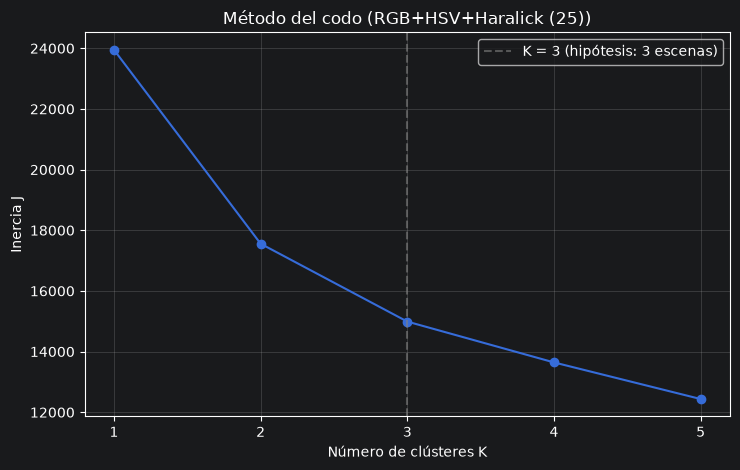

Inercias: {1: 23950.0, 2: 17556.7, 3: 14988.9, 4: 13642.9, 5: 12435.7}
Reducciones relativas de J al añadir un clúster: {'1->2': '26.7%', '2->3': '14.6%', '3->4': '9.0%', '4->5': '8.8%'}


In [77]:
# KM1. Método del codo: inercia frente a K (K = 1..5), sobre el bloque ganador
from sklearn.cluster import KMeans

ks = range(1, 6)
inercias = []
for k in ks:
    km = make_pipeline(StandardScaler(), KMeans(n_clusters=k, n_init=10, random_state=42)).fit(Xg)
    inercias.append(km.named_steps['kmeans'].inertia_)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(list(ks), inercias, 'o-')
ax.axvline(3, color='gray', linestyle='--', alpha=0.6, label='K = 3 (hipótesis: 3 escenas)')
ax.set_xlabel('Número de clústeres K')
ax.set_ylabel('Inercia J')
ax.set_title(f'Método del codo ({bloque_ganador})')
ax.set_xticks(list(ks))
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
guardar(fig, 'figura9_codo_kmeans')
plt.show()
print('Inercias:', {k: round(j, 1) for k, j in zip(ks, inercias)})
print('Reducciones relativas de J al añadir un clúster:',
      {f'{a}->{b}': f'{(inercias[a-1] - inercias[b-1]) / inercias[a-1]:.1%}' for a, b in zip(ks, ks[1:])})

Tabla de contingencia clúster vs clase real (todas las imágenes):
|   Clúster |   coast |   forest |   highway |
|----------:|--------:|---------:|----------:|
|         0 |      14 |      290 |        11 |
|         1 |     175 |       26 |       111 |
|         2 |     171 |       12 |       148 |

Mapeo clúster -> clase mayoritaria: {0: 'forest', 1: 'coast', 2: 'coast'}
Accuracy extrínseca de K-means (K=3, sobre el dataset completo): 0.6639

Figura guardada: figuras/figura10_matriz_confusion_kmeans.png


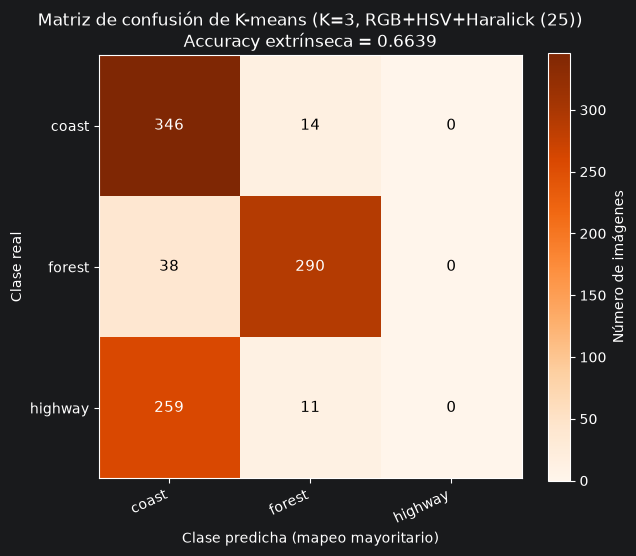

In [78]:
# KM2. K-means definitivo con K=3: contingencia clúster-clase y matriz de confusión extrínseca (conteos absolutos)
km3 = make_pipeline(StandardScaler(), KMeans(n_clusters=3, n_init=10, random_state=42)).fit(Xg)
etiquetas_cluster = km3.named_steps['kmeans'].labels_

# Tabla de contingencia: ¿qué clase real cae en cada clúster?
contingencia = pd.crosstab(etiquetas_cluster, y_ampl, rownames=['Clúster'], colnames=['Clase real'])
print('Tabla de contingencia clúster vs clase real (todas las imágenes):')
print(contingencia.to_markdown())
print()

# Mapeo clúster -> clase mayoritaria (pseudo-clasificador)
mapeo = {cl: contingencia.idxmax(axis=1)[cl] for cl in contingencia.index}
print('Mapeo clúster -> clase mayoritaria:', mapeo)
pred_kmeans = np.array([mapeo[cl] for cl in etiquetas_cluster])

acc_kmeans = accuracy_score(y_ampl, pred_kmeans)
print(f'Accuracy extrínseca de K-means (K=3, sobre el dataset completo): {acc_kmeans:.4f}')
print()

# Matriz de confusión con CONTEOS ABSOLUTOS (sin normalize)
cm_km = confusion_matrix(y_ampl, pred_kmeans, labels=clases)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im_ = ax.imshow(cm_km, cmap='Oranges')
ax.set_xticks(range(len(clases)), clases, rotation=25, ha='right')
ax.set_yticks(range(len(clases)), clases)
for i in range(len(clases)):
    for j in range(len(clases)):
        ax.text(j, i, f'{cm_km[i, j]}', ha='center', va='center', fontsize=11,
                color='white' if cm_km[i, j] > cm_km.max() / 2 else 'black')
fig.colorbar(im_, ax=ax, label='Número de imágenes')
ax.set_xlabel('Clase predicha (mapeo mayoritario)')
ax.set_ylabel('Clase real')
ax.set_title(f'Matriz de confusión de K-means (K=3, {bloque_ganador})\nAccuracy extrínseca = {acc_kmeans:.4f}')
fig.tight_layout()
guardar(fig, 'figura10_matriz_confusion_kmeans')
plt.show()